# Hammerhead Overnight Optimization — 2026-04-13

Analysis of the first Hammerhead optimization run.
- **Hull**: Hammerhead (destroyer, 8 weapon slots)
- **Sampler**: TPE (multivariate, constant liar)
- **Opponents**: 10 active per build (from 54 total pool)
- **Multi-fidelity**: 10 rungs with WilcoxonPruner
- **Instances**: 4 parallel Starsector instances
- **Duration**: ~8 hours (00:48 — 08:30+)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
# Load evaluation log
eval_log = []
with open('evaluation_log_snapshot_0837.jsonl') as f:
    for line in f:
        eval_log.append(json.loads(line))

print(f'Loaded {len(eval_log)} evaluated builds')
print(f'Pruned: {sum(1 for e in eval_log if e["pruned"])}')
print(f'Complete: {sum(1 for e in eval_log if not e["pruned"])}')

Loaded 45 evaluated builds
Pruned: 7
Complete: 38


In [3]:
# Build a DataFrame of completed trials
rows = []
for e in eval_log:
    build = e['build']
    weapons = {k: v for k, v in build['weapon_assignments'].items() if v is not None}
    hullmods = build['hullmods']
    
    # Opponent stats
    wins = sum(1 for r in e['opponent_results'] if r['winner'] == 'PLAYER')
    losses = sum(1 for r in e['opponent_results'] if r['winner'] == 'ENEMY')
    timeouts = sum(1 for r in e['opponent_results'] if r['winner'] == 'TIMEOUT')
    avg_duration = np.mean([r['duration_seconds'] for r in e['opponent_results']])
    avg_hp_diff = np.mean([r['hp_differential'] for r in e['opponent_results']])
    
    rows.append({
        'trial': e['trial_number'],
        'raw_fitness': e['raw_fitness'],
        'pruned': e['pruned'],
        'opponents_evaluated': e['opponents_evaluated'],
        'num_weapons': len(weapons),
        'num_hullmods': len(hullmods),
        'flux_vents': build['flux_vents'],
        'flux_capacitors': build['flux_capacitors'],
        'wins': wins,
        'losses': losses,
        'timeouts': timeouts,
        'avg_duration': avg_duration,
        'avg_hp_diff': avg_hp_diff,
        'weapons_str': ', '.join(sorted(weapons.values())),
        'hullmods_str': ', '.join(sorted(hullmods)),
    })

df = pd.DataFrame(rows)
df_complete = df[~df['pruned']].copy()
df_complete = df_complete.sort_values('raw_fitness', ascending=False)
print(f'{len(df)} total, {len(df_complete)} complete')
df_complete.head(10)

45 total, 38 complete


,trial,raw_fitness,pruned,opponents_evaluated,num_weapons,num_hullmods,flux_vents,flux_capacitors,wins,losses,timeouts,avg_duration,avg_hp_diff,weapons_str,hullmods_str
44,554,0.534415,False,10,6,7,1,1,10,0,0,114.637201,0.902171,"harpoon, heavyneedler, lightneedler, lrpdlaser...","auxiliarythrusters, blast_doors, escort_packag..."
34,544,0.424578,False,10,7,5,2,3,9,0,1,125.259741,0.854051,"amblaster, harpoon, heavyneedler, heavyneedler...","blast_doors, expanded_deck_crew, insulatedengi..."
42,552,0.409360,False,10,7,6,2,2,9,0,1,146.155191,0.897236,"amblaster, harpoon, heavyneedler, heavyneedler...","autorepair, blast_doors, high_scatter_amp, ins..."
25,535,0.402357,False,10,8,5,6,5,9,0,1,124.928947,0.860612,"arbalest, arbalest, harpoon, harpoon, pdlaser,...","blast_doors, hardened_subsystems, phase_anchor..."
3,510,0.390158,False,10,4,10,2,2,10,0,0,125.286872,0.994894,"lightdualmg, lightmg, sabot, vulcan","adaptive_coils, adaptiveshields, assault_packa..."
30,540,0.388386,False,10,7,5,2,2,9,0,1,106.576428,0.852089,"harpoon, heavyneedler, heavyneedler, lightag, ...","blast_doors, expanded_deck_crew, recovery_shut..."
11,520,0.317710,False,10,7,3,16,16,9,0,1,92.875389,0.754568,"annihilator, heatseeker, heavymauler, hveldriv...","hardenedshieldemitter, targetingunit, turretgyros"
21,530,0.295170,False,10,6,3,4,5,9,0,1,137.678941,0.699607,"atropos, chaingun, hammer, heavymg, lightdualm...","fluxdistributor, nav_relay, safetyoverrides"
41,551,0.284065,False,10,8,6,3,3,8,0,2,129.670008,0.930398,"harpoon, harpoon, heavymauler, heavyneedler, l...","advancedshieldemitter, blast_doors, frontemitt..."
26,536,0.253602,False,10,8,3,5,5,9,1,0,126.046562,0.751171,"harpoon, harpoon, heavyneedler, heavyneedler, ...","advancedoptics, expanded_deck_crew, surveying_..."


## 2. Fitness Over Time

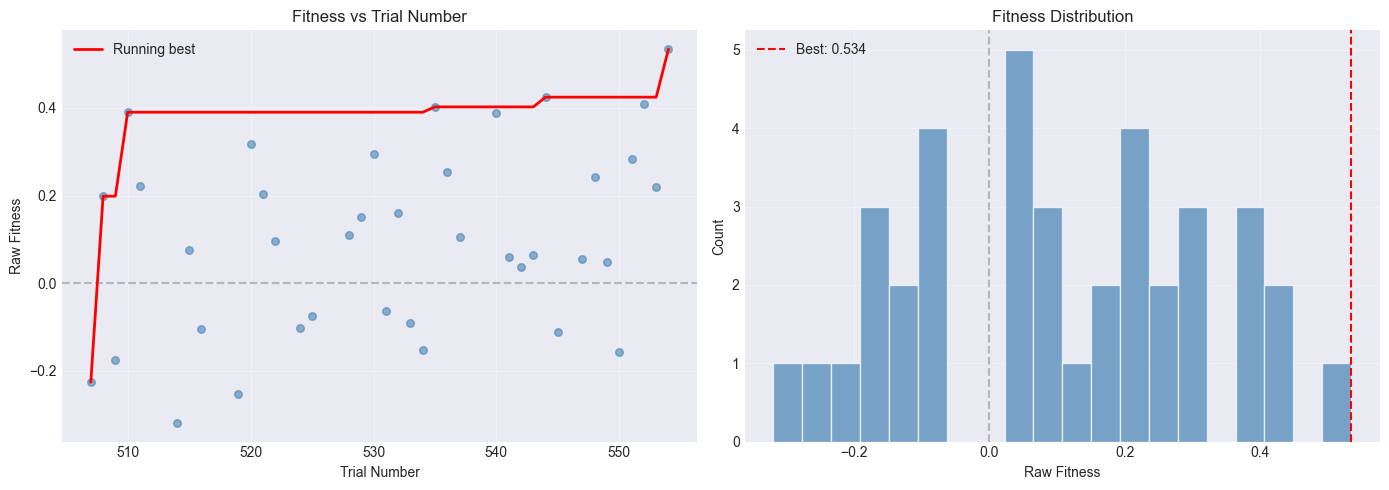

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All trials by trial number
ax1.scatter(df_complete['trial'], df_complete['raw_fitness'], alpha=0.6, s=30, c='steelblue')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Running best
running_best = df_complete.sort_values('trial')['raw_fitness'].cummax()
ax1.plot(df_complete.sort_values('trial')['trial'], running_best, color='red', linewidth=2, label='Running best')
ax1.set_xlabel('Trial Number')
ax1.set_ylabel('Raw Fitness')
ax1.set_title('Fitness vs Trial Number')
ax1.legend()

# Fitness distribution
ax2.hist(df_complete['raw_fitness'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=df_complete['raw_fitness'].max(), color='red', linestyle='--', label=f'Best: {df_complete["raw_fitness"].max():.3f}')
ax2.set_xlabel('Raw Fitness')
ax2.set_ylabel('Count')
ax2.set_title('Fitness Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('fitness_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Win/Loss/Timeout Breakdown by Opponent

In [5]:
# Aggregate opponent results across all complete trials
opp_stats = {}
for e in eval_log:
    if e['pruned']:
        continue
    for r in e['opponent_results']:
        opp = r['opponent']
        if opp not in opp_stats:
            opp_stats[opp] = {'wins': 0, 'losses': 0, 'timeouts': 0, 'durations': [], 'hp_diffs': []}
        if r['winner'] == 'PLAYER':
            opp_stats[opp]['wins'] += 1
        elif r['winner'] == 'ENEMY':
            opp_stats[opp]['losses'] += 1
        else:
            opp_stats[opp]['timeouts'] += 1
        opp_stats[opp]['durations'].append(r['duration_seconds'])
        opp_stats[opp]['hp_diffs'].append(r['hp_differential'])

opp_df = pd.DataFrame([
    {'opponent': k, 'wins': v['wins'], 'losses': v['losses'], 'timeouts': v['timeouts'],
     'total': v['wins'] + v['losses'] + v['timeouts'],
     'win_rate': v['wins'] / (v['wins'] + v['losses'] + v['timeouts']),
     'avg_duration': np.mean(v['durations']),
     'avg_hp_diff': np.mean(v['hp_diffs'])}
    for k, v in opp_stats.items()
]).sort_values('win_rate')

print(opp_df.to_string(index=False))

                opponent  wins  losses  timeouts  total  win_rate  avg_duration  avg_hp_diff
           condor_Attack     4      24        10     38  0.105263    275.349819    -0.586569
           drover_Strike    18       0        20     38  0.473684    260.243022     0.459247
         drover_Starting    21       1        16     38  0.552632    262.071395     0.650734
          condor_Support    34       0         4     38  0.894737    167.666998     0.922534
           condor_Strike    37       0         1     38  0.973684    197.522895     0.926719
        buffalo_Standard    38       0         0     38  1.000000     37.710770     1.000000
       berserker_Assault    38       0         0     38  1.000000     37.764252     1.000000
      bastillon_Standard    38       0         0     38  1.000000     44.043931     1.000000
buffalo2_Fighter_Support    38       0         0     38  1.000000     34.510712     1.000000
             buffalo2_FS    38       0         0     38  1.000000     

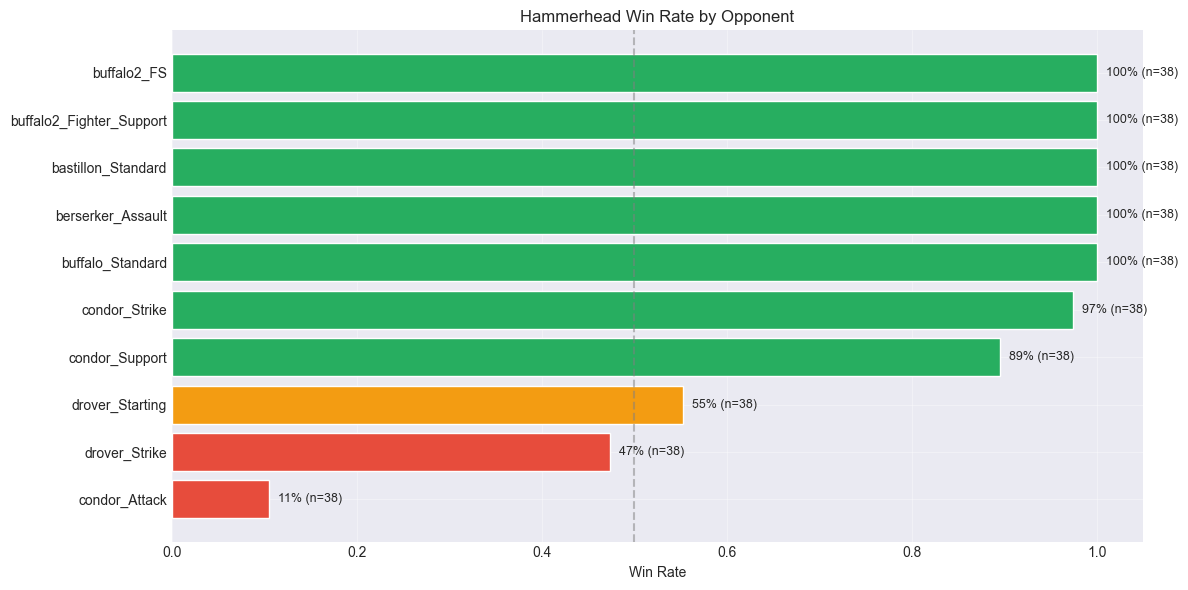

In [6]:
# Opponent difficulty chart
fig, ax = plt.subplots(figsize=(12, 6))
opp_sorted = opp_df.sort_values('win_rate')
colors = ['#e74c3c' if wr < 0.5 else '#f39c12' if wr < 0.8 else '#27ae60' for wr in opp_sorted['win_rate']]
bars = ax.barh(opp_sorted['opponent'], opp_sorted['win_rate'], color=colors, edgecolor='white')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Win Rate')
ax.set_title('Hammerhead Win Rate by Opponent')
for i, (wr, total) in enumerate(zip(opp_sorted['win_rate'], opp_sorted['total'])):
    ax.text(wr + 0.01, i, f'{wr:.0%} (n={total})', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('opponent_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Top Builds — Weapons & Hullmods

In [7]:
# Top 10 builds
for i, (_, row) in enumerate(df_complete.head(10).iterrows()):
    e = next(e for e in eval_log if e['trial_number'] == row['trial'])
    build = e['build']
    weapons = {k: v for k, v in build['weapon_assignments'].items() if v is not None}
    print(f"\n#{i+1} Trial {row['trial']} — fitness {row['raw_fitness']:.3f}")
    print(f"  Weapons ({len(weapons)}): {', '.join(f'{k}={v}' for k, v in sorted(weapons.items()))}")
    print(f"  Hullmods ({len(build['hullmods'])}): {', '.join(sorted(build['hullmods']))}")
    print(f"  Vents={build['flux_vents']}, Caps={build['flux_capacitors']}")
    print(f"  Record: {row['wins']}W/{row['losses']}L/{row['timeouts']}T, avg duration={row['avg_duration']:.0f}s")


#1 Trial 554 — fitness 0.534
  Weapons (6): WS 001=heavyneedler, WS 003=harpoon, WS 005=pdlaser, WS 006=lightneedler, WS 007=lrpdlaser, WS 008=lrpdlaser
  Hullmods (7): auxiliarythrusters, blast_doors, escort_package, expanded_deck_crew, recovery_shuttles, shrouded_lens, unstable_injector
  Vents=1, Caps=1
  Record: 10W/0L/0T, avg duration=115s

#2 Trial 544 — fitness 0.425
  Weapons (7): WS 001=heavyneedler, WS 002=heavyneedler, WS 003=harpoon, WS 005=lightag, WS 006=lrpdlaser, WS 007=amblaster, WS 008=lightmortar
  Hullmods (5): blast_doors, expanded_deck_crew, insulatedengine, recovery_shuttles, shrouded_lens
  Vents=2, Caps=3
  Record: 9W/0L/1T, avg duration=125s

#3 Trial 552 — fitness 0.409
  Weapons (7): WS 001=heavyneedler, WS 002=heavyneedler, WS 003=harpoon, WS 005=lightag, WS 006=mininglaser, WS 007=amblaster, WS 008=lightmortar
  Hullmods (6): autorepair, blast_doors, high_scatter_amp, insulatedengine, recovery_shuttles, shrouded_lens
  Vents=2, Caps=2
  Record: 9W/0L/1T, 

## 5. Weapon & Hullmod Frequency in Top Builds

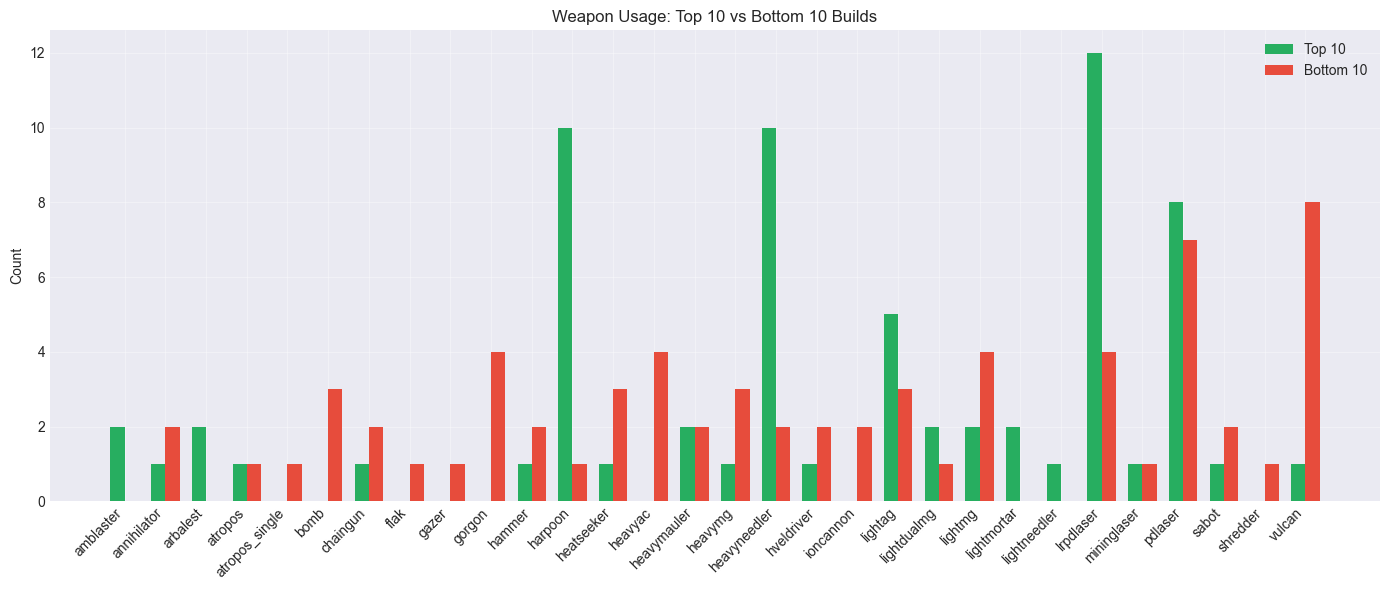

In [8]:
# Weapon frequency in top 10 vs bottom 10
def get_weapon_counts(trial_numbers):
    counts = Counter()
    for e in eval_log:
        if e['trial_number'] in trial_numbers:
            for w in e['build']['weapon_assignments'].values():
                if w is not None:
                    counts[w] += 1
    return counts

top10_trials = set(df_complete.head(10)['trial'])
bottom10_trials = set(df_complete.tail(10)['trial'])

top_weapons = get_weapon_counts(top10_trials)
bottom_weapons = get_weapon_counts(bottom10_trials)

all_weapons = sorted(set(top_weapons.keys()) | set(bottom_weapons.keys()))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_weapons))
width = 0.35
ax.bar(x - width/2, [top_weapons.get(w, 0) for w in all_weapons], width, label='Top 10', color='#27ae60')
ax.bar(x + width/2, [bottom_weapons.get(w, 0) for w in all_weapons], width, label='Bottom 10', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(all_weapons, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Weapon Usage: Top 10 vs Bottom 10 Builds')
ax.legend()
plt.tight_layout()
plt.savefig('weapon_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

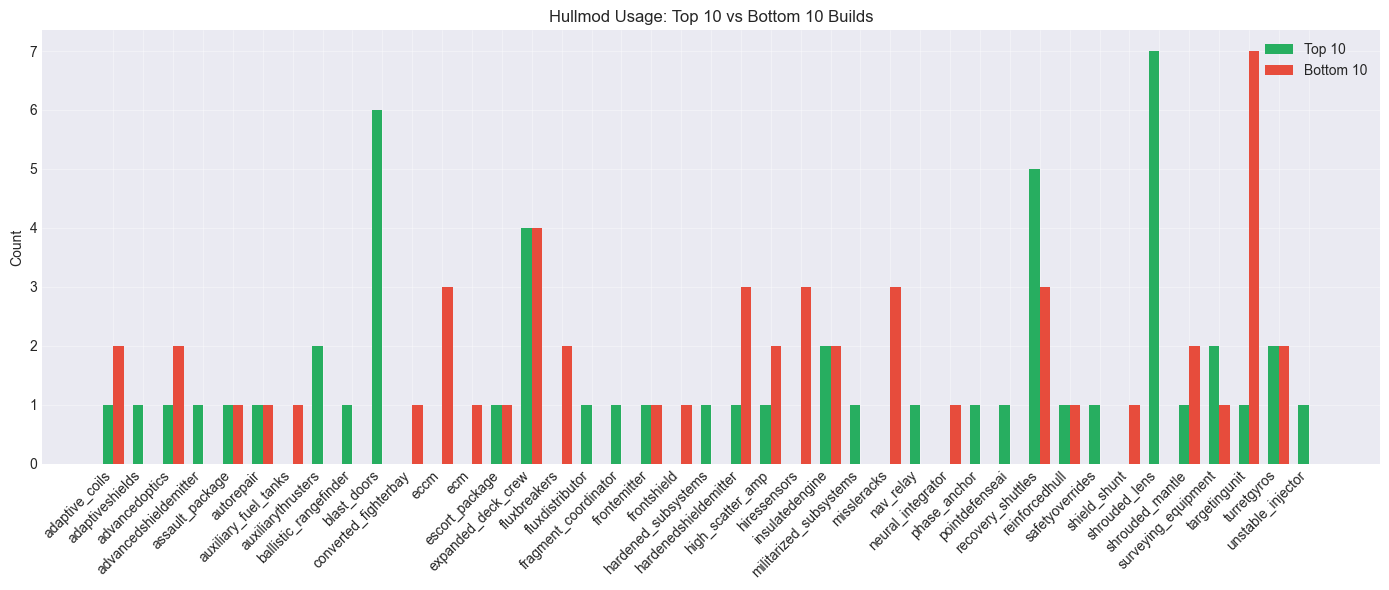

In [9]:
# Hullmod frequency in top 10 vs bottom 10
def get_hullmod_counts(trial_numbers):
    counts = Counter()
    for e in eval_log:
        if e['trial_number'] in trial_numbers:
            for m in e['build']['hullmods']:
                counts[m] += 1
    return counts

top_mods = get_hullmod_counts(top10_trials)
bottom_mods = get_hullmod_counts(bottom10_trials)

all_mods = sorted(set(top_mods.keys()) | set(bottom_mods.keys()))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_mods))
width = 0.35
ax.bar(x - width/2, [top_mods.get(m, 0) for m in all_mods], width, label='Top 10', color='#27ae60')
ax.bar(x + width/2, [bottom_mods.get(m, 0) for m in all_mods], width, label='Bottom 10', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(all_mods, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Hullmod Usage: Top 10 vs Bottom 10 Builds')
ax.legend()
plt.tight_layout()
plt.savefig('hullmod_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Flux Allocation Patterns

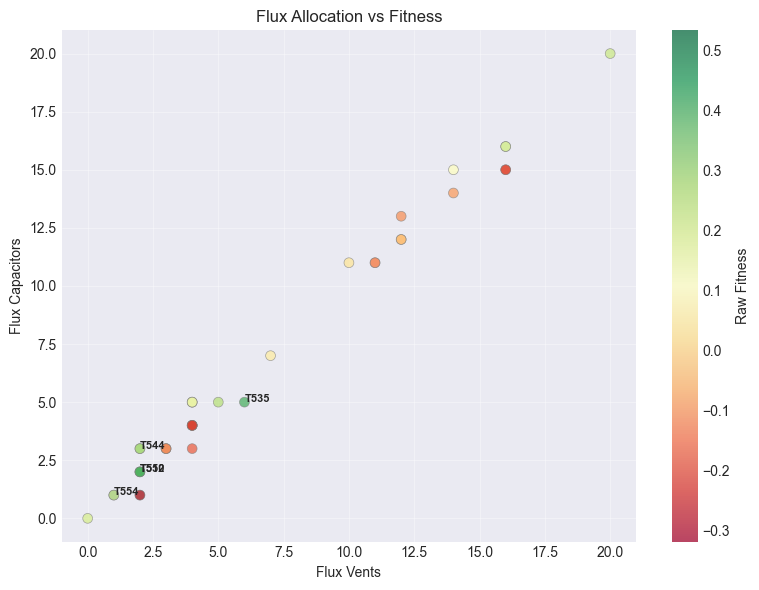

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_complete['flux_vents'], df_complete['flux_capacitors'], 
                     c=df_complete['raw_fitness'], cmap='RdYlGn', 
                     s=50, alpha=0.7, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, label='Raw Fitness')
ax.set_xlabel('Flux Vents')
ax.set_ylabel('Flux Capacitors')
ax.set_title('Flux Allocation vs Fitness')

# Mark top 5
for _, row in df_complete.head(5).iterrows():
    ax.annotate(f'T{int(row["trial"])}', (row['flux_vents'], row['flux_capacitors']),
               fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('flux_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Combat Duration Analysis

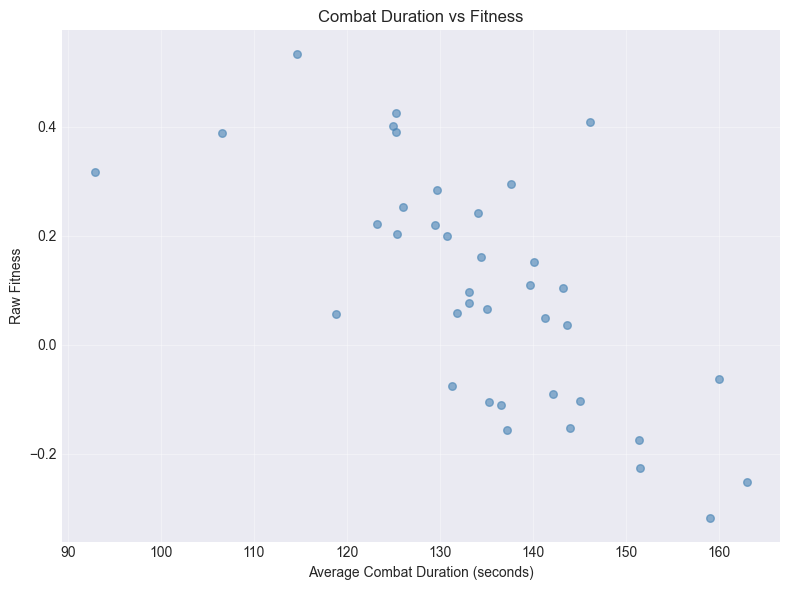

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_complete['avg_duration'], df_complete['raw_fitness'], 
           alpha=0.6, s=30, c='steelblue')
ax.set_xlabel('Average Combat Duration (seconds)')
ax.set_ylabel('Raw Fitness')
ax.set_title('Combat Duration vs Fitness')
plt.tight_layout()
plt.savefig('duration_vs_fitness.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Pruning Efficiency

In [12]:
pruned = df[df['pruned']]
complete = df[~df['pruned']]

print(f'Total sim trials: {len(df)}')
print(f'Complete: {len(complete)} ({len(complete)/len(df)*100:.0f}%)')
print(f'Pruned: {len(pruned)} ({len(pruned)/len(df)*100:.0f}%)')
if len(pruned) > 0:
    print(f'\nPruned at rung (opponents evaluated):')
    print(pruned['opponents_evaluated'].value_counts().sort_index())
    matchups_saved = sum(10 - n for n in pruned['opponents_evaluated'])
    print(f'\nMatchups saved by pruning: {matchups_saved}')
    print(f'Estimated time saved: ~{matchups_saved * 2:.0f} minutes')

Total sim trials: 45
Complete: 38 (84%)
Pruned: 7 (16%)

Pruned at rung (opponents evaluated):
opponents_evaluated
5    1
6    1
7    1
8    1
9    3
Name: count, dtype: int64

Matchups saved by pruning: 17
Estimated time saved: ~34 minutes


## 9. Summary Statistics

In [13]:
print('=== Hammerhead Overnight Optimization Summary ===')
print(f'Total sim trials: {len(df)} ({len(complete)} complete, {len(pruned)} pruned)')
print(f'Best fitness: {df_complete["raw_fitness"].max():.4f} (trial {df_complete.iloc[0]["trial"]:.0f})')
print(f'Median fitness: {df_complete["raw_fitness"].median():.4f}')
print(f'Mean fitness: {df_complete["raw_fitness"].mean():.4f}')
print(f'Std fitness: {df_complete["raw_fitness"].std():.4f}')
print(f'\nPositive fitness (net winner): {(df_complete["raw_fitness"] > 0).sum()} / {len(df_complete)}')
print(f'Negative fitness (net loser): {(df_complete["raw_fitness"] < 0).sum()} / {len(df_complete)}')
print(f'\nAvg weapons per build: {df_complete["num_weapons"].mean():.1f}')
print(f'Avg hullmods per build: {df_complete["num_hullmods"].mean():.1f}')
print(f'Avg vents: {df_complete["flux_vents"].mean():.1f}')
print(f'Avg caps: {df_complete["flux_capacitors"].mean():.1f}')

=== Hammerhead Overnight Optimization Summary ===
Total sim trials: 45 (38 complete, 7 pruned)
Best fitness: 0.5344 (trial 554)
Median fitness: 0.1006
Mean fitness: 0.1030
Std fitness: 0.2152

Positive fitness (net winner): 26 / 38
Negative fitness (net loser): 12 / 38

Avg weapons per build: 6.7
Avg hullmods per build: 5.2
Avg vents: 6.8
Avg caps: 6.9
